In [ ]:
# Continious Integration на примере Gitlab-CI.Часть 1.

### ИНИЦИАЛИЗАЦИЯ ВЕБ-ПРИЛОЖЕНИЯ. GIT

#### **ПЕРЕХОДИМ В VS CODE**

**Декоратор в Python** — это функция, которая принимает другую функцию в качестве аргумента, добавляет к ней дополнительную функциональность и возвращает функцию с изменённым поведением.

Декораторы позволяют изменять поведение функций и классов с помощью добавления или изменения их функциональности без изменения самого кода.

Принцип работы декоратора:
- Принимает функцию как аргумент.
- Объявляет новую функцию, которая расширяет функцию-аргумент.
- Возвращает новую функцию в качестве объекта.

Для избегания прямого присвоения функций, в Python используют конструкцию @<имя декоратора, которая автоматически декорирует выбранную функцию.

In [ ]:
def hello():
    print("hi")

In [ ]:
hello()

hi


In [ ]:
def hello_bye():
    print("bye")
    hello()
    print("bye")

In [ ]:
hello_bye()

hi
bye


Сначала необходимо установить Flask. Сделать это можно с помощью pip:

`pip install flask`

Теперь импортируем его и создадим объект Flask-приложения.


```
from flask import Flask
app = Flask(__name__)
```


Мы передаём __name__ при инициализации класса Flask, чтобы определить имя, с которым будет использоваться этот модуль. Flask использует расположение файла как точку, к которой он привязывает ресурсы.

> Совет. В абсолютном большинстве случаев можно передавать аргумент __name__ для инициализации класса — приложение будет настроено верно.

Теперь мы можем написать функцию, которая будет обрабатывать запросы, и прикрепить её к какому-то пути (URI). Это делается с помощью специального декоратора route.

```
@app.route('/hello')
def hello_func():
    return 'hello!'
```

Наша функция пока не делает никакой обработки и просто отвечает строкой с приветствием. Нам осталось запустить приложение. Для этого выполним метод run, не забыв занести его в стандартный main.

```
if __name__ == '__main__':
    app.run('localhost', 5000)
```

>В блоке if __name__ == '__main__' прописывается код, который не должен выполняться при импорте модуля. Переменная __name__ — это специальная переменная, которая будет равна "__main__", только если файл запускается как основная программа, и выставляется равной имени модуля при импорте модуля.

Например, если мы захотим импортировать файл server.py как внешний модуль,

```
from server import *
```

то код, указанный в блоке if __name__ == '__main__', соответствующий запуску сервера, не будет выполнен.

Мы запускаем наш сервис в строке app.run('localhost', 5000), указывая адрес сетевого интерфейса и порт, на котором будет работать сервер. В нашем случае мы работаем на локальной машине по IP-адресу 127.0.0.1, или localhost (то есть доступ к сервису может быть получен только с нашего компьютера), а номер порта, по которому можно отправлять запросы, — 5000.

Вы должны увидеть примерно такой текст:

```
* Serving Flask app "server" (lazy loading)

* Environment: production
   WARNING: This is a development server. Do not use it in a production deployment.
   Use a production WSGI server instead.
* Debug mode: off
* Running on http://localhost:5000/ (Press CTRL+C to quit)
```

После запуска программа перейдёт в режим прослушивания сети.

Теперь откройте браузер и зайдите по адресу http://localhost:5000/hello.

Вы увидите текст hello!, а в логах — строку с кодом обработки вашего запроса.

> Чтобы прервать работу программы-сервера в VS Code, нажмите сочетание клавиш CTRL + C, находясь в поле терминала. После этого перезапустите скрипт.

- Напишим новую функцию index(), которая будет возвращать строку "Test message. The server is running".
- Обернем эту функцию в декоратор app.route(), указав в качестве эндпоинта '/'. Данный эндпоинт будет соответствовать обращению к сайту по дефолтному адресу: http://localhost:5000/.

- Перезапустим веб-сервис и зайдите по этому адресу. В поле для ответа введите код обработки, который вернулся в результате выполнения GET-запроса.

```
@app.route('/')
def index():
    return "Test message. The server is running"
```

Для выполнения запроса используется ссылка http://localhost:5000/.

### ПЕРЕДАЧА ПАРАМЕТРОВ ЗАПРОСА

Давайте немного усложним логику обработки — создадим функцию, которая принимает какой-то параметр и использует его для вычисления результата.

Параметры можно передавать тремя способами:
- через адресную строку;
- через заголовки;
- через тело.

В заголовках обычно передают сервисные параметры. Так как у метода GET не бывает тела, остаются только параметры адресной строки.

> Вы наверняка видели параметры на сайтах, когда в конец адреса дописывается что-то вроде ?id=10&page=2. Если поставить в конце адреса вопросительный знак, то после него можно добавлять параметры. Передавать можно любые параметры — они будут перечисляться через & и состоять из имени и значения (id=10). Например, если вы будете что-то искать в Google, ваш запрос будет видно в адресной строке в параметре с названием q (от англ. query).

Параметры запроса во Flask находятся в специальном объекте request, который нужно импортировать. Параметры адресной строки можно найти в поле args этого объекта, где args — это словарь.

> Давайте немного модифицируем наш код — теперь сервер будет здороваться и обращаться по имени. Для этого занесём параметр name, полученный из request, в переменную и воспользуемся этим значением, поставив его в форматированную строку.

```
from flask import Flask, request

app = Flask(__name__)
@app.route('/hello')

def hello_func():
    name = request.args.get('name')
    return f'hello {name}!'

if __name__ == '__main__':

    app.run('localhost', 5000)
```

Перезапустите сервер и зайдите по адресу http://localhost:5000/hello?name=world.

В результате выполнения запроса вы должны увидеть в браузере текст "hello world".

> Поменяйте значение параметра name в адресной строке на своё имя и выполните новый запрос к серверу, чтобы проверить, что при изменении параметра адресной строки меняется и возвращаемый результат.

Напишем функцию current_time, которая будет возвращать словарь, где ключ — 'time', а значение — текущее время.

> Примечание. Текущее время можно узнать с помощью модуля datetime:

```
from flask import Flask
import datetime
app = Flask(__name__)

@app.route('/time')
def current_time():
    return {'time': datetime.datetime.now()}
if __name__ == '__main__':
    app.run('localhost', 5000)
```

### POST-ЗАПРОСЫ

Пока что мы написали обработчик GET-запроса.

Если мы хотим обрабатывать и другие методы, например POST-запросы, это необходимо указать в декораторе:
```
@app.route('/add', methods=['POST'])
``

> Что должна возвращать функция-обработчик? Она будет возвращать объект Response, в котором мы должны были бы задать все компоненты ответа: код обработки, заголовки и тело. К счастью, Flask (а точнее, объект Response) умеет и превращать в ответы другие объекты, и самостоятельно формировать ответ.

Например, строка
```
return f'hello {name}!'
```
преобразуется в ответ с кодом 200 и телом, состоящим из этой строки:

```
return f'hello {name}!', 200
```

Также можно возвращать кортеж из двух элементов, строки и числа. Число используется как код обработки.

> Вспомогательная функция jsonify поможет преобразовать обычный питоновский словарь в ответ в формате JSON, который очень часто используется для передачи структурированных данных.

Вооружившись этими знаниями, напишем обработчик POST-запроса, который будет читать тело запроса в JSON-формате и составлять ответ на основе его содержимого.
```
from flask import Flask, request, jsonify

app = Flask(__name__)
```

Укажем, что функция обрабатывает метод POST:

```
@app.route('/add', methods=['POST'])
```
Напишем саму функцию:
```
def add():
    num = request.json.get('num')
```

Параметры тела доступны в поле data. Но если тело — это JSON-строка, то можно использовать поле json.

Напишем проверку и укажем код ошибки:
```
    if num > 10:
        return 'too much', 400

    return jsonify({
        'result': num + 1
    })
```

Тогда функция-обработчик будет иметь следующий вид:

```
@app.route('/add', methods=['POST'])
def add():
    num = request.json.get('num')
    if num > 10:
        return 'too much', 400
    return jsonify({
        'result': num + 1
    })
```

Запускаем:
```
if __name__ == '__main__':
    app.run('localhost', 5000)
```

К сожалению, браузеры не умеют писать POST-запросы самостоятельно. Это реализуется только через клиентские приложения, поэтому нам не хватит обычного браузера, чтобы проверить сервис.

> Если вы любите визуальные редакторы запросов, рекомендуем обратить внимание на Postman.

Напишем простой сервис в соседнем скрипте, используя библиотеку requests, которая позволяет отправлять HTTP-запросы. Для этого создадим отдельный файл client.py, в котором опишем работу программы клиента.

Чтобы выполнить POST-запрос, нужно просто вызвать соответствующую функцию и передать ей адрес (URL) и содержимое тела запроса.

```
import requests
if __name__ == '__main__':
    r = requests.post('http://localhost:5000/add', json={'num': 5})
```

Далее выведем статус-код ответа:
```
print(r.status_code)
```

Теперь пропишем проверку:
```
if r.status_code == 200:
   print(r.json()['result'])
else:
   print(r.text)
```

Полный код нашего простейшего клиентского приложения будет выглядеть так:

```
import requests

if __name__ == '__main__':
    # выполняем POST-запрос на сервер по эндпоинту add с параметром json
    r = requests.post('http://localhost:5000/add', json={'num': 5})
    # выводим статус запроса
    print(r.status_code)
    # реализуем обработку результата
    if r.status_code == 200:
        # если запрос выполнен успешно (код обработки=200),
        # выводим результат на экран
        print(r.json()['result'])
    else:
        # если запрос завершён с кодом, отличным от 200,
        # выводим содержимое ответа
        print(r.text)
```

> Чтобы запустить код клиентского приложения параллельно работающему серверу в VS Code, создайте новый терминал и запустите файл client.py вручную, написав в терминале команду:

python client.py

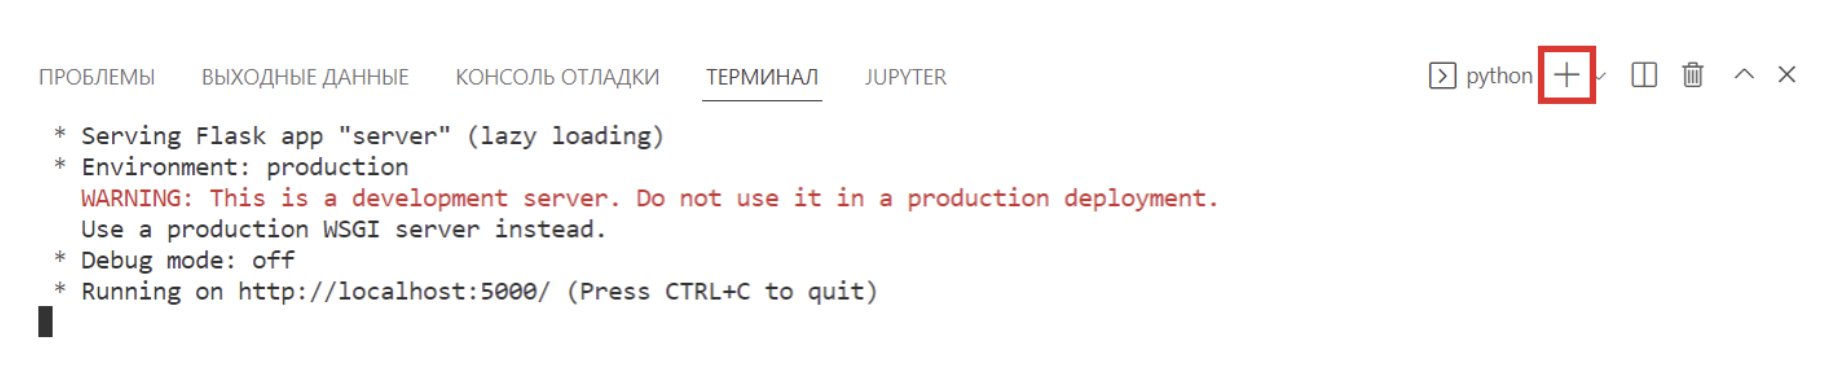

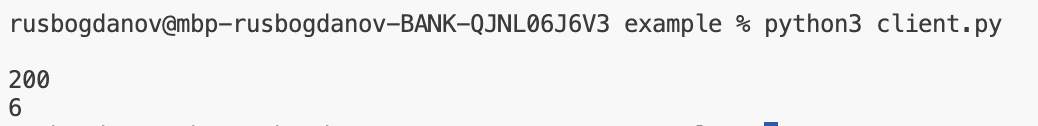

### ДЕПЛОИМ МОДЕЛЬ НА ВЕБ-СЕРВИС

Нам необходимо написать веб-сервис, который позволит клиентам делать запросы к нашей модели. В ответ клиенты должны получать ответы — предсказания модели.

> У модели, как всегда, есть метод predict, который принимает на вход numpy-массив размерности (кол-во объектов; кол-во признаков). Всего у нас четыре анонимных признака, и их интерпретация сейчас не имеет значения.

Давайте обернём процедуру предсказания модели в обработчик POST-запросов.

> В теле POST-запроса — список из четырёх чисел в формате JSON (один объект, четыре признака). Эти числа можно извлечь из запроса следующим образом:

```
features = request.json
```

Так как на вход модели необходимо подать numpy-массив определённой размерности, а не список, не забудьте перевести результат в тип np.array() и скорректировать его под размер (1, 4) с помощью reshape():

```
features = np.array(features).reshape(1, 4)
```

После этого подайте полученный вектор на вход модели и получите результат.

> Обратите внимание, что результатом предсказания также станет не число, а numpy-массив, пусть и состоящий из одного числа. Нас же интересует именно предсказанное число, поэтому не забудьте извлечь результат из полученного массива (обратившись по индексу 0).

Ответом на запрос должен быть JSON-формат {"prediction": *число - предсказание модели*}.

Файл server.py

```
from flask import Flask, request, jsonify
import pickle
import numpy as np

# загружаем модель из файла
with open('model.pkl', 'rb') as pkl_file:
    model = pickle.load(pkl_file)

# создаём приложение
app = Flask(__name__)

@app.route('/')
def index():
    msg = "Тестовое сообщение. Сервер запущен!"
    return msg

@app.route('/predict', methods=['POST'])
def predict():
    #ваш код здесь
    features = np.array(request.json)
    features = features.reshape(1, 4)
    prediction = model.predict(features)
    return  jsonify({'prediction': prediction[0]})
    # pass

if __name__ == '__main__':
    app.run('localhost', 5000)
```

Файл client.py

```
import requests

if __name__ == '__main__':
    # выполняем POST-запрос на сервер по эндпоинту add с параметром json
    r = requests.post('http://localhost:5000/predict', json=[1, 0, 1, 24])
    # выводим статус запроса
    print('Status code: {}'.format(r.status_code))
    # реализуем обработку результата
    if r.status_code == 200:
        # если запрос выполнен успешно (код обработки=200),
        # выводим результат на экран
        print('Prediction: {}'.format(r.json()['prediction']))
    else:
        # если запрос завершён с кодом, отличным от 200,
        # выводим содержимое ответа
        print(r.text)
```

### GIT

In [ ]:
https://git-scm.com/downloads

SyntaxError: invalid syntax (<ipython-input-1-2c1591e91198>, line 1)

Контроль версий (контроль исходного кода) — практика, которая позволяет отслеживать изменения исходного кода и управлять ими.

> **Рассмотрим практическую задачу.** Мы создали сайт, он работает, пользователи не испытывают проблем. Но прошло время и мы решили изменить функциональность. Прежде чем вносить изменения, сохраняем рабочую версию сайта на компьютере или сервере. Это будет архив «Рабочая версия нашего сайта». Спустя время появляется еще одна версия нашего сайта, допустим, 2.0. При возникновении проблем всегда можно откатиться до первой версии и запустить сайт заново.

**Контроль версий необходим, чтобы:**

- хранить разные версии проекта;
- возвращаться к разным версиям проекта.

**Примеры:** версии сайтов (по датам) и документов.

Хранение версий сводится к созданию копий информации на компьютере или сервере. Функцию возврата реализуют за счёт восстановления предыдущих версий.

Таким образом, **система контроля** — это реализованная возможность замены информации с использованием сохраненных версий

**Примеры использования контроля версий в жизни:**

- Написание нескольких версий одного текста
- Сохранение в компьютерных играх.
    - Если вы сделали что-то неправильно, вы всегда можете вернуться к состоянию, когда вас всё устраивало.
- Группа сотрудников пишет текст в течение нескольких дней.
    - Когда готов первый черновик, его отправляют на ревью коллеге. Пока он читает, другие сотрудники продолжают работу над текстом. И когда ревьюер «выкатывает» комментарии к первой версии черновика, у команды уже появился «Черновик 2». После внесения правок появляется ещё и «Черновик 3». Файлы множатся и работа усложняется.

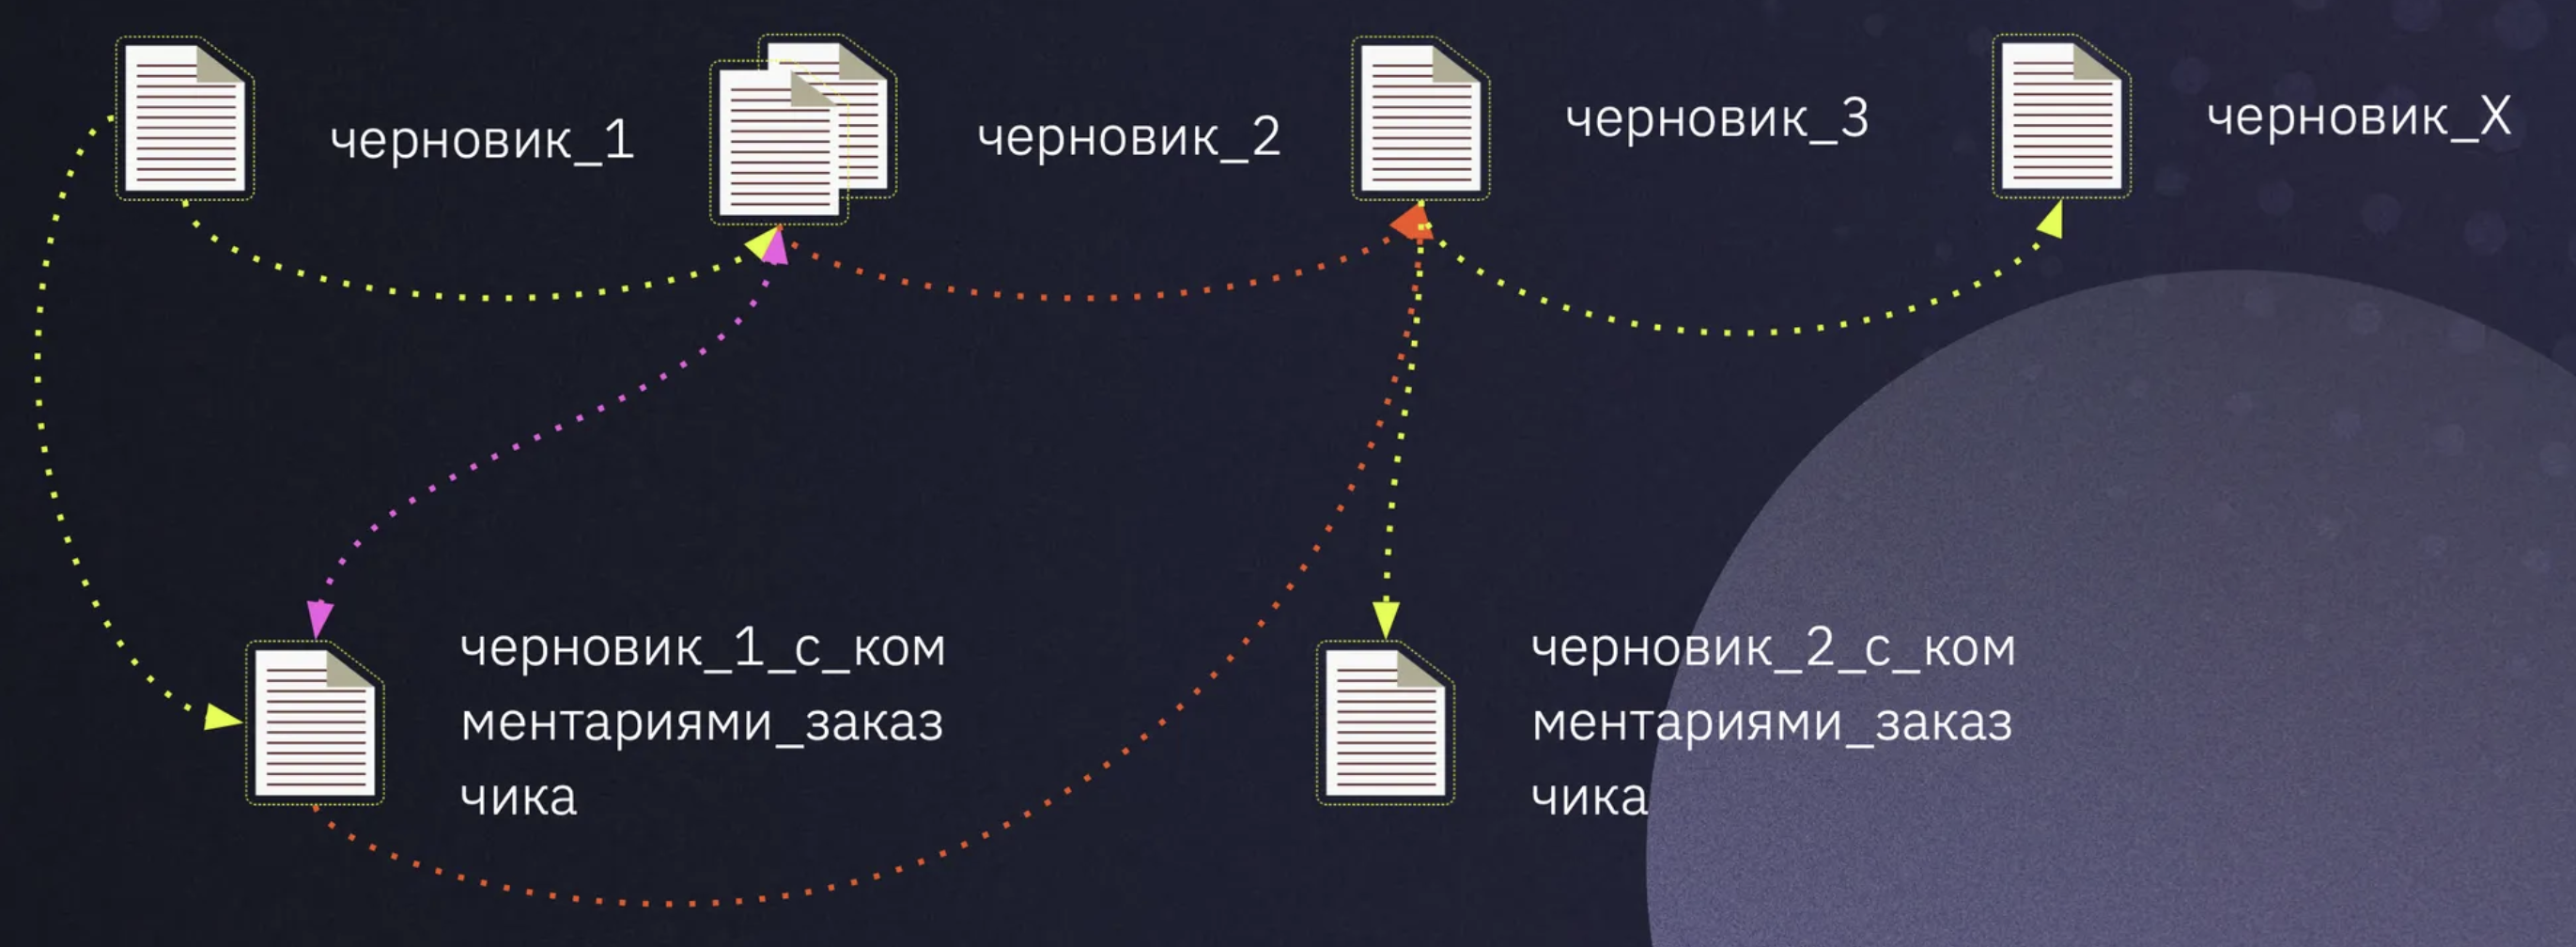

В программировании проблемы совместной работы над проектами возникли ещё до появления облачных сервисов.  


**Git** — самая популярная система контроля версий, но не единственная. Алгоритм работы подобных систем схож.



Программа Git берёт на себя контроль версий проекта и позволяет переключаться между ними. Обратите внимание: Git хранит **не файлы целиком, а отличия между ними**. Это позволяет экономить память. Автор программы — Линус Торвальдс, создатель ОС Linux.

### **Команды Git**

Осваивать Git проще процессе редактирования текстовых файлов. Markdown  - язык разметки, который позволяет форматировать текст. Для написания в редакторе VS Code используется синтаксис языка.

Команды markdown - https://gist.github.com/Jekins/2bf2d0638163f1294637



Прежде чем создавать репозиторий и инициализировать Git, проверим текущую установленную версию программы. Для этого в терминале введём команду:

```
git --version
```

Если Git установлен на компьютер, вы увидите его текущую версию.

Программа использует мнемонические команды, которые легко запомнить, если знать английский язык.

#### Создание  Git-репозитория:

- Берём локальный каталог, который не находится под версионным контролем, и превращаем его в репозиторий.
- Клонируем существующий репозиторий из любого места.

**Команда git init**

- Инициализация: указываем папку, в которой git начнёт отслеживать изменения
- В папке создаётся скрытая папка .git

**Команда git status**

- Показывает текущее состояние гита, есть ли изменения, которые нужно закоммитить (сохранить)


> Чтобы вызвать ранее введённую команду, пользуемся стрелками на клавиатуре. Перебираем недавно введённые команды нажатием стрелки «вверх».



**Команда git add**

- добавляет содержимое рабочего каталога в индекс (staging area) для последующего коммита. Эта команда дается после добавления файлов. Писать название целиком не обязательно: терминал дозаполнит данные автоматически.

**Команда git commit**

- зафиксировать или сохранить

По умолчанию **git** **commit** использует лишь этот индекс, так что вы можете использовать **git add** для сборки слепка вашего следующего коммита.

Команда **git commit** берёт все данные, добавленные в индекс с помощью **git** **add**, и сохраняет их слепок во внутренней базе данных, а затем сдвигает указатель текущей ветки на этот слепок.

**Команда git log**

- Журнал изменений
- Перед переключением версии файла в Git используйте команду **git log**, чтобы увидеть количество сохранений

**Команда git checkout**

- Переключение между версиями.
- Для работы нужно указать не только интересующий вас коммит, но и вернуться в тот, где работаем, при помощи команды **git checkout master**.

 - **git checkout master**. -- для github
 - **git checkout main**. -- для git(локально)

> Нажатие клавиши ‘**q**’ возвращает в исходное окно терминала.

**Команда git diff**

- показывает разницу между текущим файлом и сохранённым

### Ветки

**Ветки (branches)** в Git нужны для организации параллельной работы над проектом. Они позволяют разработчикам работать над новыми функциями, исправлениями ошибок или экспериментальными изменениями, не влияя на основной код, пока работа не будет завершена и проверена.

Для чего они нужны:

- Ветки позволяют изолировать изменения, чтобы избежать случайного изменения основной версии кода. Например, можно создать ветку для исправления ошибки, пока основная ветка остаётся стабильной.

- Ветки дают возможность нескольким разработчикам одновременно работать над разными задачами в одном проекте. Каждый разработчик может создать свою ветку и работать независимо от других.

- Позволяют легко отслеживать историю изменений для каждой функции или исправления. После завершения работы над веткой можно объединить её с основной веткой и сохранить все изменения вместе с комментариями.

- Подходят для экспериментальных изменений, которые могут не войти в основную ветку. Это удобно для тестирования новых идей или функций без риска нарушить рабочий код.

- Ветки позволяют подготовить стабильную версию для выпуска (например, с помощью веток release или hotfix), пока продолжается активная разработка новых функций.

**git branch**

Если у нас несколько версий черновика, мы можем вывести на экран ветку, где находимся, командой **git branch.**

Создать ветку можно командой **git branch**. Делать это надо в папке с репозиторием:

- *git branch <название новой ветки>*

Если потребуется переключиться с одной ветки на другую, вызовем команду **git checkout <имя ветки>**

> Команда **git log** покажет состояние более новых версий проекта. Но если вызвать эту команду из самой «свежей» ветки, мы не увидим исходного файла.

> Когда мы правим текст/код в текущей ветке, автоматического слияния не происходит: можно создавать один документ в разных версиях в разных ветках.

Допустим, черновики нас полностью устраивают и нам нужно внести изменения, чтобы информация появилась в чистовике. Для этого есть команда git merge.



#### Совмещение двух вариантов текста

**git merge**

Чтобы слить любую ветку с *текущей*, вызываем **git merge** <имя ветки для слияния с текущей>

#### Удаление веток

Если ветка text formatting больше не нужна, ее можно удалить

**git branch -d branch_to_delete**

#### Визуализация всех веток

**git log  --graph**

Ключ -graf в связке с командой log позволяет отобразить коммиты в виде дерева.

#### Конфликт изменений

При работе в двух ветках одновременно может возникнуть ситуация, когда в одной и другой ветке мы по-разному изменили блок текста. Если затем мы попробуем слить эти ветки, Git сообщит о конфликте и предложит выбрать, какие же изменения записать.

Тренажер по гиту - https://learngitbranching.js.org/?locale=ru_RU

#### Вопросы:
- Что такое ветка?
- Что такое конфликт и почему он вызывается?